In [ ]:
import os
import shutil
import numpy as np

# --- Paths and Ratios ---
extracted_path = "/content/drive/MyDrive/Colab Notebooks/covid19normalpneumonia-ct-images"
classesPath = ['Normal_CT', 'pneumonia_CT']
train_ratio, val_ratio, test_ratio = 0.6, 0.2, 0.2

# --- Prepare Balanced Dataset ---
class_file_counts = {}
for cls in classesPath:
    src = os.path.join(extracted_path, cls)
    allFileNames = os.listdir(src)
    class_file_counts[cls] = len(allFileNames)

min_files = min(class_file_counts.values())

for cls in classesPath:
    os.makedirs(os.path.join('./train/', cls), exist_ok=True)
    os.makedirs(os.path.join('./val/', cls), exist_ok=True)
    os.makedirs(os.path.join('./test/', cls), exist_ok=True)

    src = os.path.join(extracted_path, cls)
    allFileNames = os.listdir(src)
    np.random.shuffle(allFileNames)
    balanced_FileNames = allFileNames[:min_files]

    train_count = int(train_ratio * min_files)
    val_count = int(val_ratio * min_files)
    test_count = min_files - train_count - val_count

    # Calculate the split sizes
    total_files = len(balanced_FileNames)
    train_FileNames = balanced_FileNames[:train_count]
    val_FileNames = balanced_FileNames[train_count:train_count + val_count]
    test_FileNames = balanced_FileNames[train_count + val_count:]

    # Print statistics for each class
    print(f'Total {cls} after balancing: {total_files}')
    print(f'Training: {len(train_FileNames)}')
    print(f'Validation: {len(val_FileNames)}')
    print(f'Testing: {len(test_FileNames)}\n')

    for name in train_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./train/', cls))
    for name in val_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./val/', cls))
    for name in test_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./test/', cls))

Total Normal_CT after balancing: 2119
Training: 1271
Validation: 423
Testing: 425

Total pneumonia_CT after balancing: 2119
Training: 1271
Validation: 423
Testing: 425



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Directories
train_dir = 'train'
val_dir = 'val'
test_dir = 'test'


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(128, 128), class_mode='binary', batch_size=16, shuffle=True)
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(128, 128), class_mode='binary', batch_size=16, shuffle=False)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(128, 128), class_mode='binary', batch_size=16, shuffle=False)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, Conv2D,
    BatchNormalization, Multiply, Reshape, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow.keras.backend as K

# -------------------------------
# Tversky loss only
def tversky_loss(alpha=0.3, beta=0.7, smooth=1e-6):
    def loss(y_true, y_pred):
        y_true = K.cast(y_true, dtype='float32')
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        tp = K.sum(y_true * y_pred)
        fp = K.sum((1 - y_true) * y_pred)
        fn = K.sum(y_true * (1 - y_pred))
        return 1.0 - (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return loss

# -------------------------------
# Squeeze-and-Excitation Block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Dense(filters // ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([input_tensor, se])

# -------------------------------
# Data - Compute class weights
X_train_full, y_train_full = [], []
for i in range(len(train_generator)):
    X_batch, y_batch = train_generator[i]
    X_train_full.append(X_batch)
    y_train_full.append(y_batch)
    if len(X_train_full) * 16 >= train_generator.n:
        break
X_train_full = np.concatenate(X_train_full)
y_train_full = np.concatenate(y_train_full)

X_train, _, y_train, _ = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)
class_weights_dict = dict(enumerate(compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)))

# -------------------------------
# InceptionV3 Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
for layer in base_model.layers[-100:]:
    layer.trainable = True

x = base_model.output
x = squeeze_excite_block(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))(x)

model = Model(inputs=base_model.input, outputs=output)

# -------------------------------
# Compile model with only Tversky loss
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=tversky_loss(),
              metrics=['accuracy'])

# -------------------------------
# Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=5, min_lr=1e-7)

# -------------------------------
# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# -------------------------------
# Validation evaluation
val_preds = (model.predict(val_generator) > 0.5).astype(int)
val_labels = val_generator.classes
print("Validation:",
      f"Accuracy: {accuracy_score(val_labels, val_preds)}",
      f"Precision: {precision_score(val_labels, val_preds)}",
      f"Recall: {recall_score(val_labels, val_preds)}",
      f"F1: {f1_score(val_labels, val_preds)}")

# -------------------------------
# Test evaluation
X_test_full, y_test_full = [], []
for i in range(len(test_generator)):
    X_batch, y_batch = test_generator[i]
    X_test_full.append(X_batch)
    y_test_full.append(y_batch)
    if len(X_test_full) * 16 >= test_generator.n:
        break
X_test_full = np.concatenate(X_test_full)
y_test_full = np.concatenate(y_test_full)

test_preds = (model.predict(X_test_full) > 0.5).astype(int)
print("Test:",
      f"Accuracy: {accuracy_score(y_test_full, test_preds)}",
      f"Precision: {precision_score(y_test_full, test_preds)}",
      f"Recall: {recall_score(y_test_full, test_preds)}",
      f"F1: {f1_score(y_test_full, test_preds)}")


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5166 - loss: 0.3929

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


128/128 ━━━━━━━━━━━━━━━━━━━━ 146s 506ms/step - accuracy: 0.5170 - loss: 0.3925 - val_accuracy: 0.5095 - val_loss: 0.9652 - learning_rate: 1.0000e-04
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.7042 - loss: 0.2326 - val_accuracy: 0.8097 - val_loss: 0.5573 - learning_rate: 1.0000e-04
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.7984 - loss: 0.1617 - val_accuracy: 0.8428 - val_loss: 0.6123 - learning_rate: 1.0000e-04
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.8420 - loss: 0.1264 - val_accuracy: 0.8593 - val_loss: 0.5957 - learning_rate: 1.0000e-04
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 83ms/step - accuracy: 0.8952 - loss: 0.0885 - val_accuracy: 0.7861 - val_loss: 0.6535 - learning_rate: 1.0000e-04
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.8843 - loss: 0.1011 - val_accuracy: 0.9043 - val_loss: 0.5288 - learning_rate: 1.0000e-04
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accur

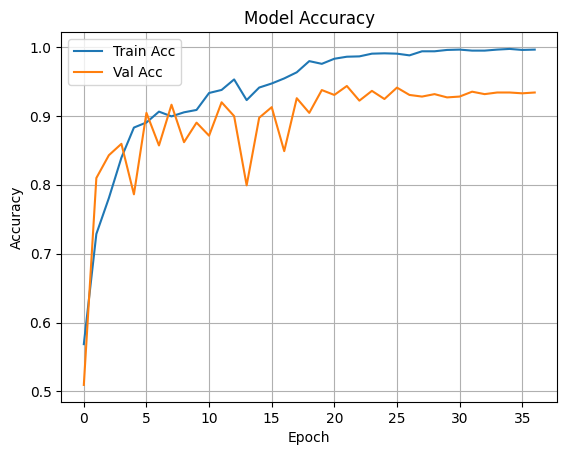

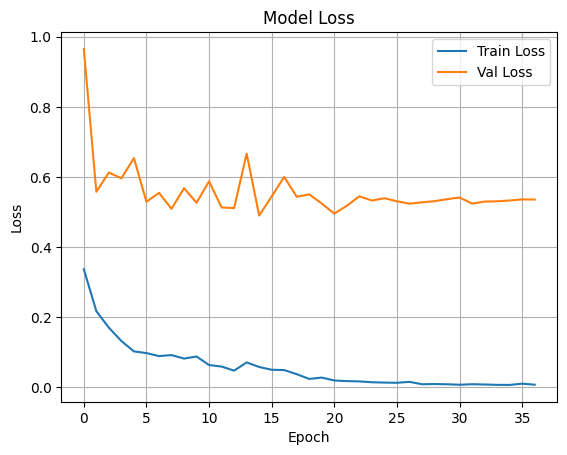

In [ ]:
import matplotlib.pyplot as plt
# --- Plots ---
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step


<Figure size 800x600 with 0 Axes>

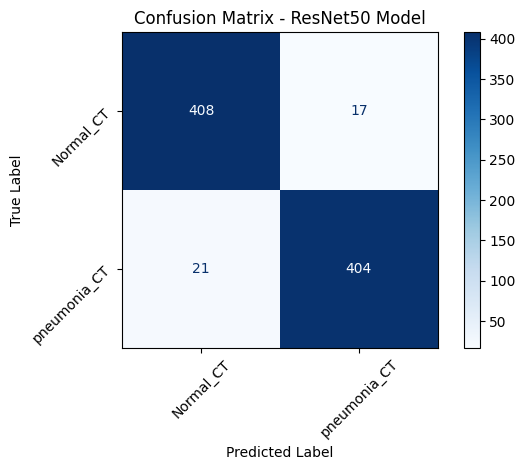

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate model on test data
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).ravel()  # Convert probabilities to class labels (0 or 1)

# True labels
y_true = test_generator.classes  # Assuming test_generator has the true labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - ResNet50 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
model.save('Inceptionv3_tverskyloss.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)
<ipython-input-28-50c1bedf4012>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


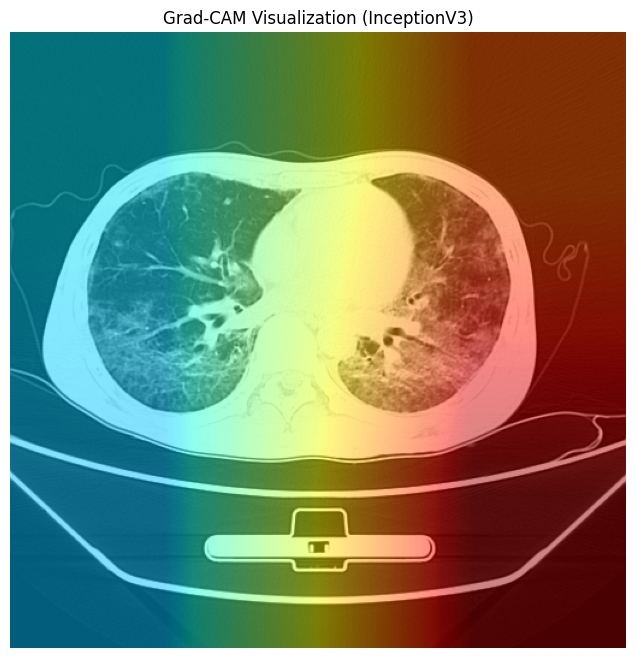

Saved Grad-CAM visualization at: gradcam_output_inceptionv3.jpg


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
import os

# Load InceptionV3 model (ImageNet pretrained)
model = tf.keras.models.load_model("Inceptionv3_tverskyloss.h5", compile=False)

# Image preprocessing function (for InceptionV3)
def preprocess_image(img_path, target_size=(128, 128)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array)

# Grad-CAM generation
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="mixed10", pred_index=None):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_output = predictions[:, pred_index]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

# Overlay heatmap on original image
def overlay_heatmap(heatmap, img_path, alpha=0.4, cmap='jet'):
    img = image.load_img(img_path)
    img = image.img_to_array(img)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (img.shape[0], img.shape[1])).numpy()
    heatmap_resized = np.uint8(255 * heatmap_resized[:, :, 0])

    jet = plt.cm.get_cmap(cmap)
    colored_heatmap = jet(heatmap_resized / 255.0)[:, :, :3]
    colored_heatmap = np.uint8(255 * colored_heatmap)

    superimposed_img = img * (1 - alpha) + colored_heatmap * alpha
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    return tf.keras.preprocessing.image.array_to_img(superimposed_img)

# Run visualization
def run_gradcam(img_path, save_path=None):
    img_array = preprocess_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model)
    superimposed_img = overlay_heatmap(heatmap, img_path)

    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.title("Grad-CAM Visualization (InceptionV3)")
    plt.show()

    # Save the image if a path is given
    if save_path:
        superimposed_img.save(save_path)
        print(f"Saved Grad-CAM visualization at: {save_path}")

# Example image path
img_path = "/content/test/pneumonia_CT/200 (40).jpg"

# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_inceptionv3.jpg")


<ipython-input-13-50c1bedf4012>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


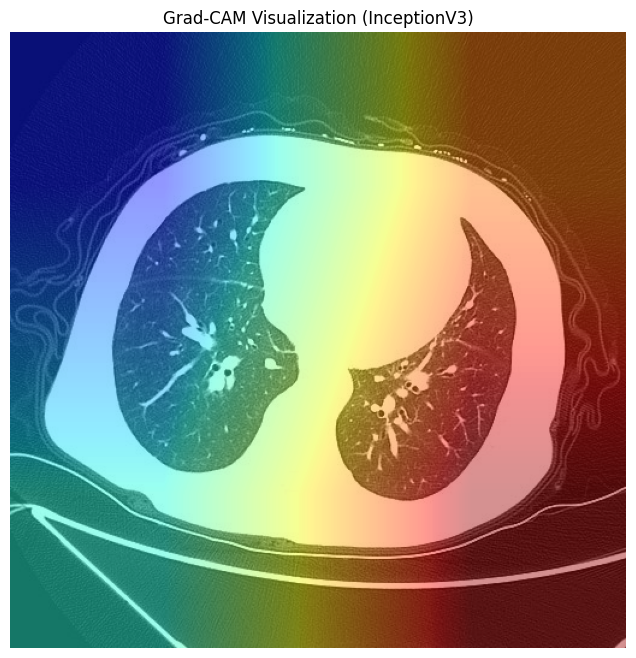

Saved Grad-CAM visualization at: gradcam_output_inceptionv3_2.jpg


In [ ]:
# Example image path
img_path = "/content/test/pneumonia_CT/204 (20).jpg"

# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_inceptionv3_2.jpg")

<ipython-input-28-50c1bedf4012>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


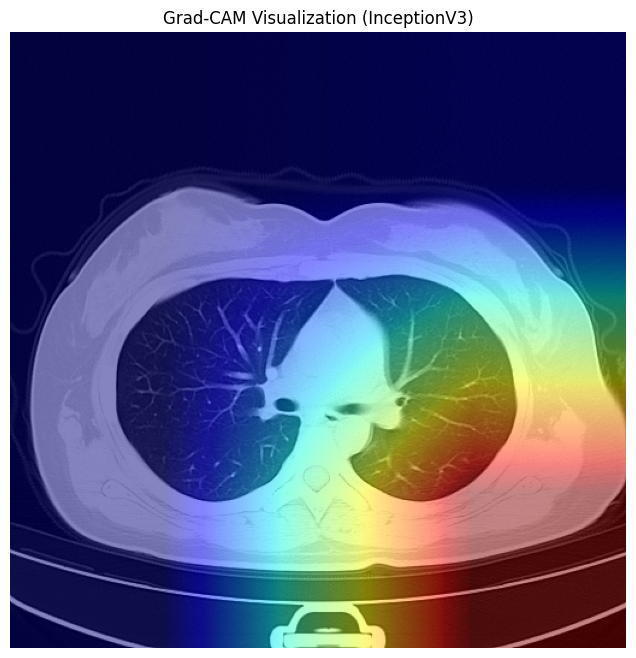

Saved Grad-CAM visualization at: gradcam_output_inceptionv3_3.jpg


In [ ]:
# Example image path
img_path = "/content/test/Normal_CT/2584f (25).jpg"

# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_inceptionv3_3.jpg")

<ipython-input-13-50c1bedf4012>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


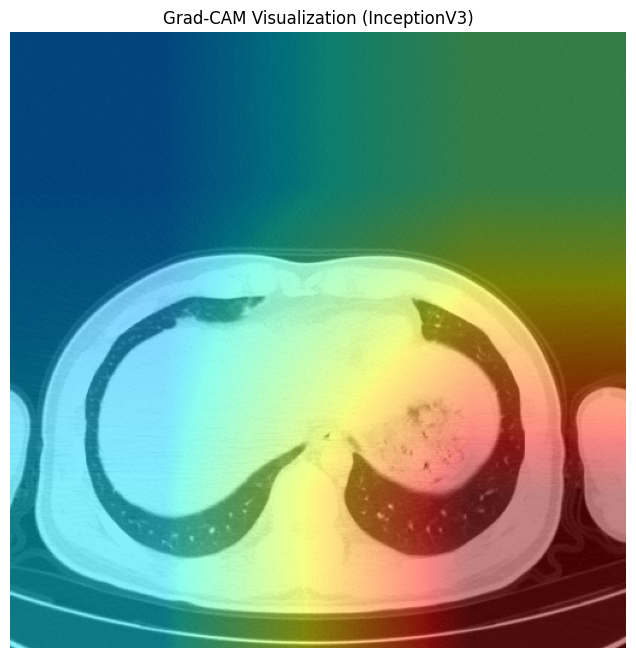

Saved Grad-CAM visualization at: gradcam_output_inceptionv3_4.jpg


In [ ]:
# Example image path
img_path = "/content/test/Normal_CT/52dfv5ds5fvv (46).jpg"

# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_inceptionv3_4.jpg")

Processing multiply with 2 inputs.


<ipython-input-10-5d984586530a>:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


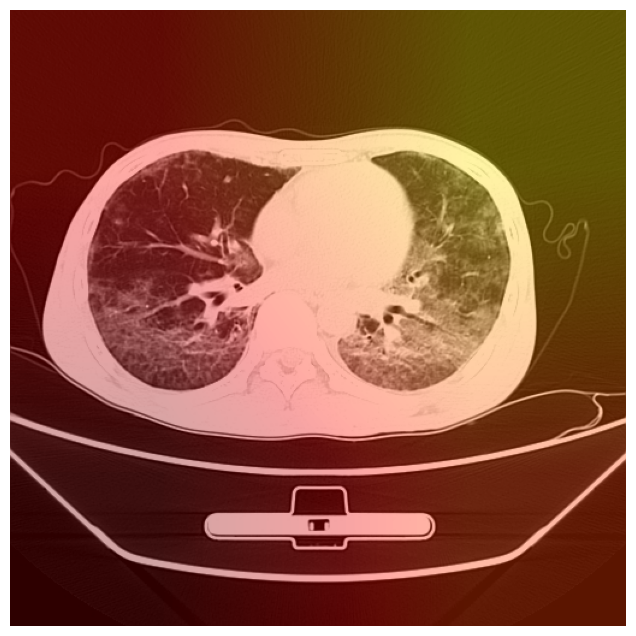

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load your fine-tuned binary InceptionV3 model
model = tf.keras.models.load_model("Inceptionv3_tverskyloss.h5", compile=False)

# Preprocessing function (keep same target size)
def preprocess_image(img_path, target_size=(128, 128)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return tf.keras.applications.inception_v3.preprocess_input(img_array)

# Compute CAM for binary classification
def compute_cam(img_array, model, last_conv_layer_name="mixed10"):
    # Get the output from the last conv layer
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_model = tf.keras.models.Model(model.input, last_conv_layer.output)

    # Get the classifier part
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # Iterate through layers, handling Multiply and Concatenate
    for layer in model.layers[model.layers.index(last_conv_layer) + 1:]:
        if isinstance(layer, (tf.keras.layers.Multiply, tf.keras.layers.Concatenate)):
            # Assuming these layers require a list of tensors as input
            try:
                # If the layer expects a specific number of inputs (e.g. 2 for Multiply)
                num_inputs = len(layer.input)
                if num_inputs == 2:
                    x = layer([x,x])  # Duplicate input if the layer needs two
                else:
                    x = layer([x] * num_inputs)
                print(f"Processing {layer.name} with {num_inputs} inputs.")  # Debugging print
            except:
                # Fallback if it's unclear how many inputs the layer needs
                x = layer([x]) # Try applying it to a single element list
                print(f"Processing {layer.name} with 1 input.")  # Debugging print
        else:
            x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    # Forward pass
    conv_output = last_conv_model(img_array)
    predictions = model(img_array)

    class_idx = 0  # Binary case: single output neuron
    class_output = predictions[:, class_idx]

    # Compute gradients of class output w.r.t conv features
    with tf.GradientTape() as tape:
        tape.watch(conv_output)
        preds = classifier_model(conv_output)
        class_output = preds[:, 0]
    grads = tape.gradient(class_output, conv_output)[0]

    # Global average pooling over gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the conv features
    conv_output = conv_output[0]
    cam = tf.reduce_sum(tf.multiply(pooled_grads, conv_output), axis=-1)

    # ReLU and normalize
    cam = tf.maximum(cam, 0)
    cam = cam / tf.reduce_max(cam)
    return cam.numpy()

# Overlay CAM
def overlay_cam(cam, img_path, alpha=0.4):
    img = image.load_img(img_path)
    img = image.img_to_array(img)

    cam = np.uint8(255 * cam)
    cam = tf.image.resize(np.expand_dims(cam, axis=-1), (img.shape[0], img.shape[1])).numpy()
    cam = np.uint8(cam[:, :, 0])

    jet = plt.cm.get_cmap("jet")
    jet_heatmap = jet(np.arange(256))[:, :3]
    jet_heatmap = np.uint8(jet_heatmap * 255)
    colored_heatmap = jet_heatmap[cam]

    superimposed_img = colored_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    return superimposed_img

# Run example
img_path = "/content/test/pneumonia_CT/200 (40).jpg"
img_array = preprocess_image(img_path)
cam = compute_cam(img_array, model, last_conv_layer_name="mixed10")
superimposed_img = overlay_cam(cam, img_path)

plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()


Processing multiply with 2 inputs.


<ipython-input-10-5d984586530a>:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


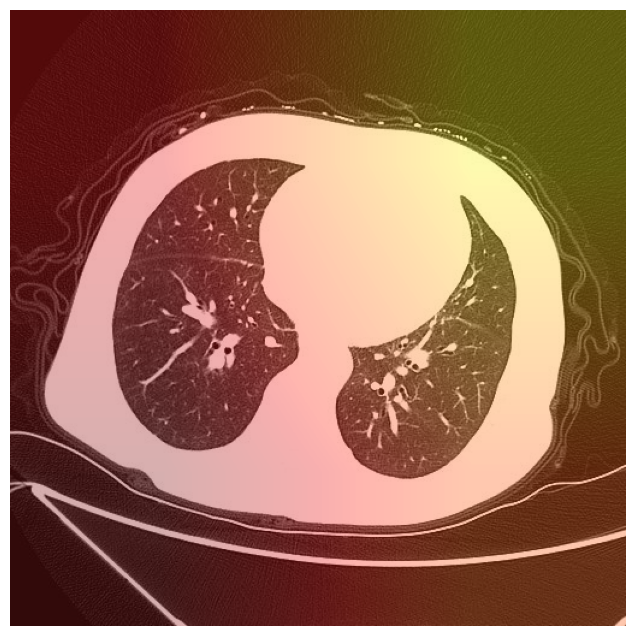

In [ ]:
# Run example
img_path = "/content/test/pneumonia_CT/204 (20).jpg"
img_array = preprocess_image(img_path)
cam = compute_cam(img_array, model, last_conv_layer_name="mixed10")
superimposed_img = overlay_cam(cam, img_path)

plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

Processing multiply with 2 inputs.


<ipython-input-10-5d984586530a>:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


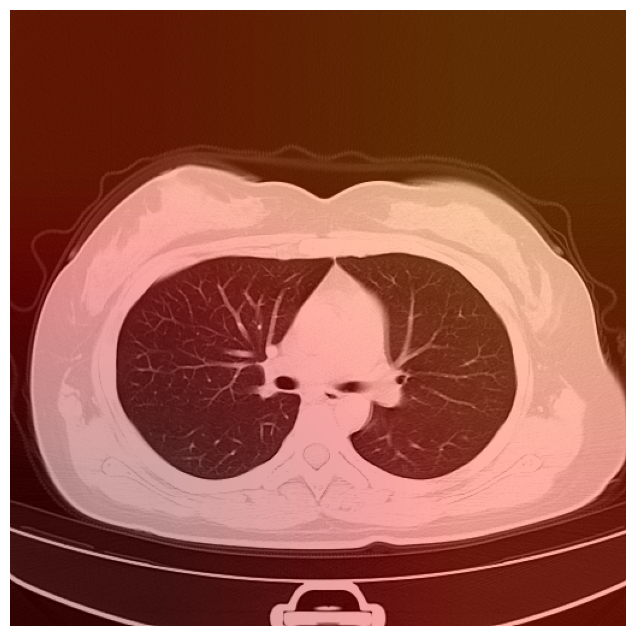

In [ ]:
# Run example
img_path = "/content/test/Normal_CT/2584f (25).jpg"
img_array = preprocess_image(img_path)
cam = compute_cam(img_array, model, last_conv_layer_name="mixed10")
superimposed_img = overlay_cam(cam, img_path)

plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

Processing multiply with 2 inputs.


<ipython-input-10-5d984586530a>:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


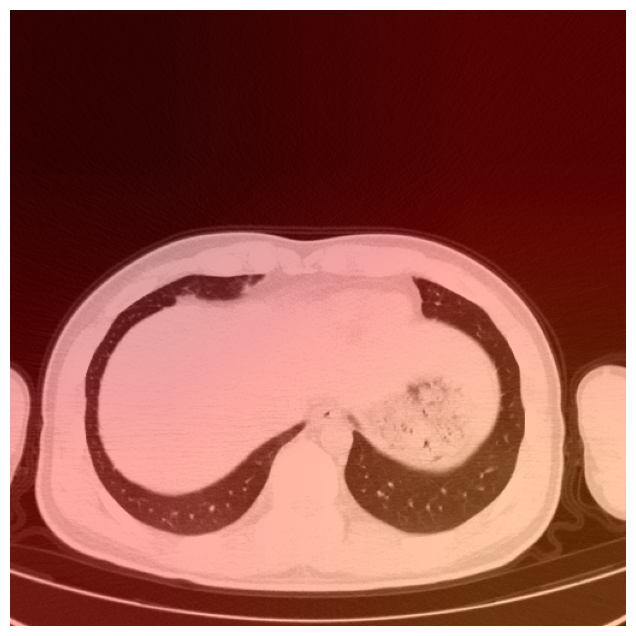

In [ ]:
# Run example
img_path = "/content/test/Normal_CT/52dfv5ds5fvv (46).jpg"
img_array = preprocess_image(img_path)
cam = compute_cam(img_array, model, last_conv_layer_name="mixed10")
superimposed_img = overlay_cam(cam, img_path)

plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e18f76191d9d25cef840175f9f0e9f3810ab0aecec9e288d2cd9a41973523690
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted: [('n04252077', 'snowmobile', np.float32(0.107629344)), ('n04229816', 'ski_mask', np.float32(0.08441908)), ('n04228054', 'ski', np.float32(0.040478654))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


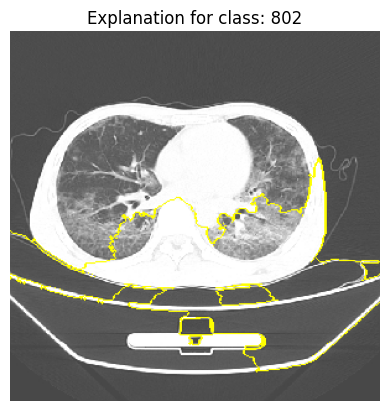

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted: [('n03595614', 'jersey', np.float32(0.66961664)), ('n04116512', 'rubber_eraser', np.float32(0.024798322)), ('n03929660', 'pick', np.float32(0.022338856))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/

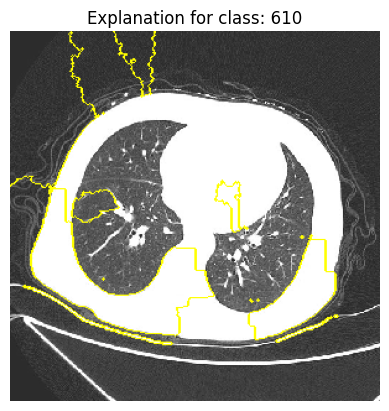

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted: [('n02910353', 'buckle', np.float32(0.67349124)), ('n02974003', 'car_wheel', np.float32(0.020217977)), ('n04019541', 'puck', np.float32(0.016951917))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 

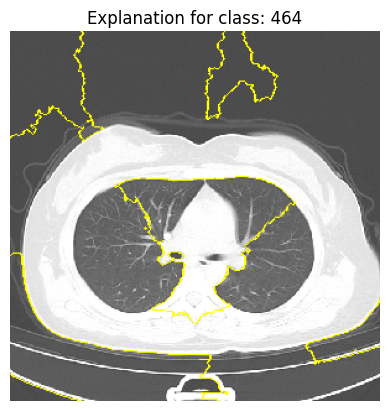

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted: [('n02910353', 'buckle', np.float32(0.20819862)), ('n07613480', 'trifle', np.float32(0.072271645)), ('n07614500', 'ice_cream', np.float32(0.063974746))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


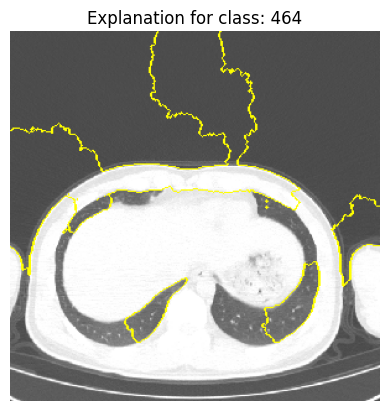

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

def explain_image_with_lime(model, img_path):
    """
    Explains the prediction of a model on a given image using LIME.

    Parameters:
    - model: A pre-trained model that will be used to make predictions.
    - img_path: The path to the image to be explained.
    """

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(299, 299))  # InceptionV3 expects 299x299
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = model.preprocess_input(img_array)

    # Get the model's prediction
    preds = model.predict(img_array)
    print('Predicted:', model.decode_predictions(preds, top=3)[0])

    # Initialize LIME image explainer
    explainer = lime_image.LimeImageExplainer()

    # Explain the prediction
    explanation = explainer.explain_instance(
        img_array[0].astype('double'),
        model.predict,
        top_labels=5,
        hide_color=0,
        num_samples=1000
    )

    # Get the explanation for the top predicted label
    top_label = np.argmax(preds)
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    # Display the image with boundaries
    plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
    plt.title(f"Explanation for class: {top_label}")
    plt.axis('off')
    plt.show()

# Example usage
if __name__ == "__main__":
    from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input, decode_predictions
    model = InceptionV3(weights='imagenet')
    model.preprocess_input = preprocess_input
    model.decode_predictions = decode_predictions

    img_path = '/content/test/pneumonia_CT/200 (40).jpg'
    explain_image_with_lime(model, img_path)

    img_path2 = '/content/test/pneumonia_CT/204 (20).jpg'
    explain_image_with_lime(model, img_path2)

    img_path3 = '/content/test/Normal_CT/2584f (25).jpg'
    explain_image_with_lime(model, img_path3)

    img_path4 = '/content/test/Normal_CT/52dfv5ds5fvv (46).jpg'
    explain_image_with_lime(model, img_path4)